# OLS, Ridge, LASSO の比較

California housing price データを使って、OLS・Ridge・LASSO を比較する。  
元の特徴量はすべて連続変数なので、そのまま使う。さらに人工的なランダム変数を追加して、LASSO が不要変数を落とす様子も確認する。

## 1. ライブラリの読み込み

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use("ggplot")

## 2. データ読み込みとノイズ変数の追加

California housing の説明変数はすべて数値変数である。  
ここでは教育用にノイズ変数を追加する。特に `noise_0`, `noise_1`, `noise_2`, `noise_3` は強く相関するように人工的に作る。

In [24]:
housing = fetch_california_housing(as_frame=True)

X = housing.data.drop(columns=["Latitude", "Longitude"]).copy()
y = housing.target.copy()

np.random.seed(42)
n_noise_features = 20

noise_0 = np.random.randn(len(X))
noise_1 = 0.99 * noise_0 + 0.01 * np.random.randn(len(X))
noise_2 = 0.99 * noise_0 + 0.01 * np.random.randn(len(X))
noise_3 = 0.99 * noise_0 + 0.01 * np.random.randn(len(X))
X["noise_0"] = noise_0
X["noise_1"] = noise_1
X["noise_2"] = noise_2
X["noise_3"] = noise_3

for i in range(4, n_noise_features):
    X[f"noise_{i}"] = np.random.randn(len(X))

original_features = [col for col in X.columns if not col.startswith("noise_")]
noise_features = [col for col in X.columns if col.startswith("noise_")]

print("Original X shape:", housing.data.shape)
print("Augmented X shape:", X.shape)
print("Number of original features:", len(original_features))
print("Number of noise features   :", len(noise_features))
print("Correlation between noise_0 and noise_1:", round(X[["noise_0", "noise_1"]].corr().iloc[0, 1], 4))
display(X.head())
display(y.head())

Original X shape: (20640, 8)
Augmented X shape: (20640, 26)
Number of original features: 6
Number of noise features   : 20
Correlation between noise_0 and noise_1: 0.9999


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,noise_0,noise_1,noise_2,noise_3,...,noise_10,noise_11,noise_12,noise_13,noise_14,noise_15,noise_16,noise_17,noise_18,noise_19
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,0.496714,0.476512,0.504430,0.496921,...,-0.931604,-0.346367,-0.401429,-0.642130,0.378650,0.345086,-1.406857,0.435348,-2.835930,1.216889
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,-0.138264,-0.132633,-0.131666,-0.124359,...,0.541254,-0.762588,1.067248,-2.556423,0.095425,0.217871,-1.030771,0.965547,1.317531,0.052153
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,0.647689,0.640498,0.650436,0.641367,...,-0.067800,-0.388925,-1.468053,-0.392929,-1.162823,0.440864,0.913514,0.952406,0.031577,-1.950098
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,1.523030,1.520229,1.516112,1.510913,...,1.380369,-0.936149,0.315741,-2.195058,0.430398,-0.468004,0.265117,0.052450,-1.391486,0.482017
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,-0.234153,-0.220089,-0.233493,-0.245636,...,-0.620669,0.122479,-0.212700,-1.064814,-0.772666,1.874458,-0.754902,0.450487,-1.584496,0.826385


,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


## 3. train / test に分割

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (16512, 26) (16512,)
Test : (4128, 26) (4128,)


## 4. 標準化

Ridge や LASSO では penalty の効き方を揃えるため、train データで標準化してから test に適用する。

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. OLS, Ridge, LASSO を比較

In [27]:
models = {
    "OLS": LinearRegression(),
    "Ridge(alpha=1.0)": Ridge(alpha=1.0),
    "Lasso(alpha=0.03)": Lasso(alpha=0.03, max_iter=20000)
}

results = []
coef_dict = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    coef = pd.Series(model.coef_, index=X.columns)

    results.append({
        "model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "nonzero_coef": int((coef != 0).sum()),
        "zero_coef": int((coef == 0).sum())
    })
    coef_dict[name] = coef

results_df = pd.DataFrame(results)
coef_df = pd.DataFrame(coef_dict)

display(results_df)
display(coef_df.head(15))

,model,RMSE,R2,nonzero_coef,zero_coef
0,OLS,0.802096,0.509040,26,0
1,Ridge(alpha=1.0),0.802158,0.508965,26,0
2,Lasso(alpha=0.03),0.809227,0.500272,5,21


,OLS,Ridge(alpha=1.0),Lasso(alpha=0.03)
MedInc,1.040240,1.039979,0.816095
HouseAge,0.211748,0.211797,0.182521
AveRooms,-0.534833,-0.534274,-0.065688
AveBedrms,0.483977,0.483481,0.040721
Population,0.026353,0.026394,0.000000
AveOccup,-0.053385,-0.053378,-0.016517
noise_0,1.065135,0.313972,-0.000000
noise_1,-0.105843,0.049263,-0.000000
noise_2,-0.911274,-0.454495,-0.000000
noise_3,-0.050440,0.088856,-0.000000


## 6. 係数の比較

人工ノイズ変数も含めて係数を比較する。LASSO では一部の係数がちょうど 0 になる。

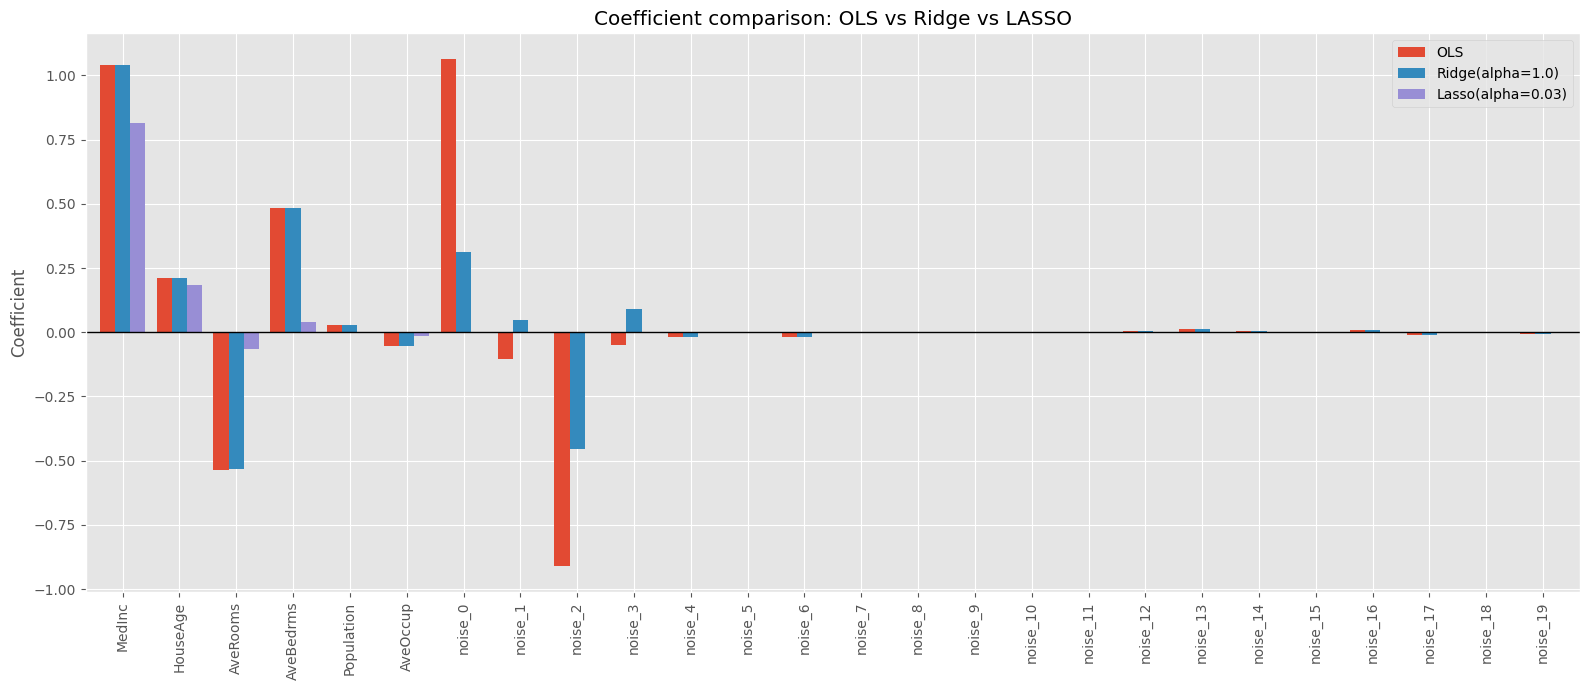

In [28]:
coef_plot_df = coef_df.copy()
coef_plot_df.plot(kind="bar", figsize=(16, 7), width=0.8)
plt.axhline(0, color="black", linewidth=1)
plt.title("Coefficient comparison: OLS vs Ridge vs LASSO")
plt.ylabel("Coefficient")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 7. LASSO で alpha を変える

`alpha` を大きくするほど shrinkage が強くなり、ゼロになる係数が増える。

In [29]:
alphas = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]

summary = []
coef_table = pd.DataFrame(index=X.columns)

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=20000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)

    coef = pd.Series(lasso.coef_, index=X.columns)
    coef_table[f"alpha={alpha}"] = coef

    summary.append({
        "alpha": alpha,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "nonzero_coef": int((coef != 0).sum()),
        "zero_coef": int((coef == 0).sum())
    })

summary_df = pd.DataFrame(summary)
display(summary_df)
display(coef_table.head(20))

,alpha,RMSE,R2,nonzero_coef,zero_coef
0,0.001,0.801209,0.510126,20,6
1,0.003,0.799584,0.512111,15,11
2,0.010,0.796788,0.515516,10,16
3,0.030,0.809227,0.500272,5,21
4,0.100,0.825733,0.479677,2,24
5,0.300,0.888284,0.397861,1,25


,alpha=0.001,alpha=0.003,alpha=0.01,alpha=0.03,alpha=0.1,alpha=0.3
MedInc,1.032722,1.017673,0.965386,0.816095,0.711482,0.49852
HouseAge,0.210729,0.208563,0.200707,0.182521,0.106500,0.00000
AveRooms,-0.519125,-0.487735,-0.378615,-0.065688,-0.000000,0.00000
AveBedrms,0.469078,0.439275,0.335758,0.040721,0.000000,-0.00000
Population,0.025113,0.022548,0.013495,0.000000,-0.000000,-0.00000
AveOccup,-0.052130,-0.049581,-0.040796,-0.016517,-0.000000,-0.00000
noise_0,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000
noise_1,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000
noise_2,-0.001494,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000
noise_3,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.00000


## 8. LASSO の係数パス

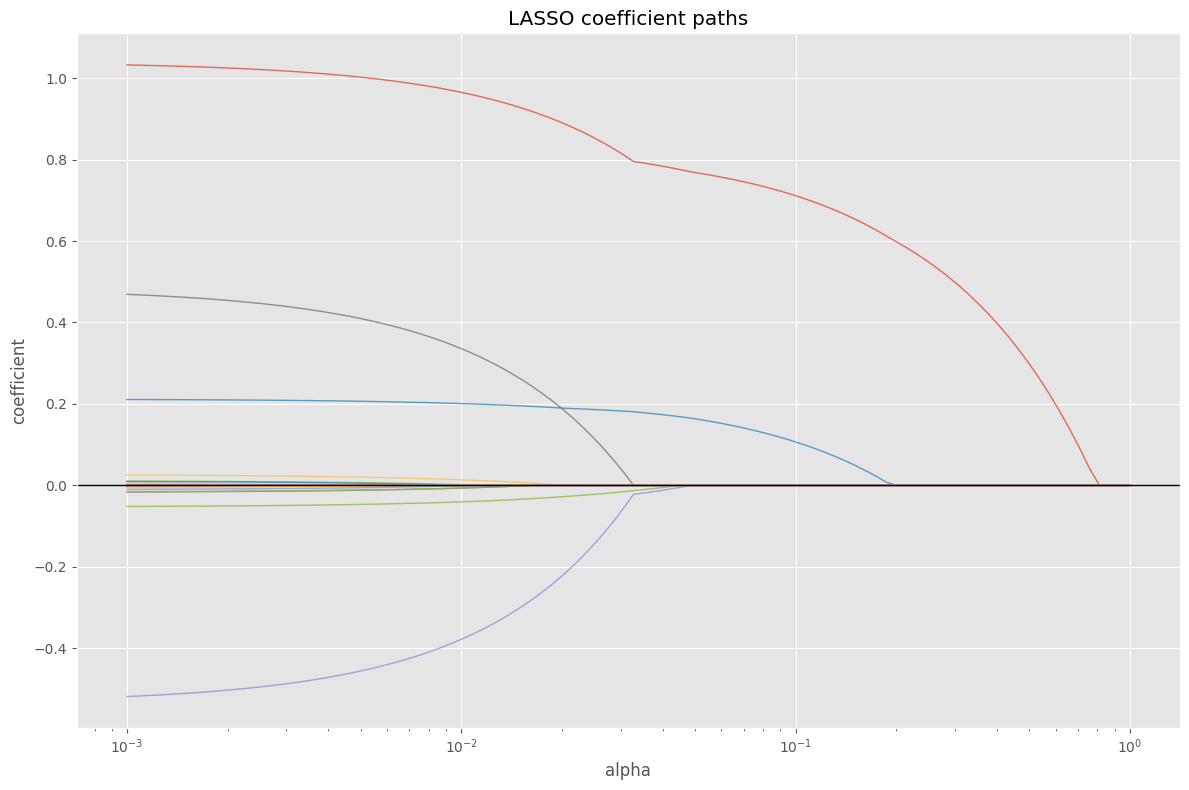

In [30]:
alphas_plot = np.logspace(-3, 0, 100)
coefs = []

for alpha in alphas_plot:
    lasso = Lasso(alpha=alpha, max_iter=20000)
    lasso.fit(X_train_scaled, y_train)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(12, 8))
for i, col in enumerate(X.columns):
    plt.plot(alphas_plot, coefs[:, i], linewidth=1, alpha=0.8)

plt.xscale("log")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("alpha")
plt.ylabel("coefficient")
plt.title("LASSO coefficient paths")
plt.tight_layout()
plt.show()

## 9. LassoCV で alpha を自動選択

In [ ]:
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_cv.fit(X_train_scaled, y_train)

y_pred_cv = lasso_cv.predict(X_test_scaled)
coef_cv = pd.Series(lasso_cv.coef_, index=X.columns)

print("Best alpha:", lasso_cv.alpha_)
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_cv)))
print("Test R2   :", r2_score(y_test, y_pred_cv))
print("Non-zero coefficients:", int((coef_cv != 0).sum()))
print("Zero coefficients    :", int((coef_cv == 0).sum()))

display(coef_cv.sort_values(key=np.abs, ascending=False).head(20))

Best alpha: 0.00261479157123276
Test RMSE : 0.8882842738896318
Test R2   : 0.5117643237379449
Non-zero coefficients: 15
Zero coefficients    : 11


,0
MedInc,1.020549
AveRooms,-0.493737
AveBedrms,0.444977
HouseAge,0.208990
AveOccup,-0.050068
Population,0.023047
noise_4,-0.014791
noise_6,-0.014012
noise_13,0.008783
noise_17,-0.008438


## 10. LassoCV の係数を可視化

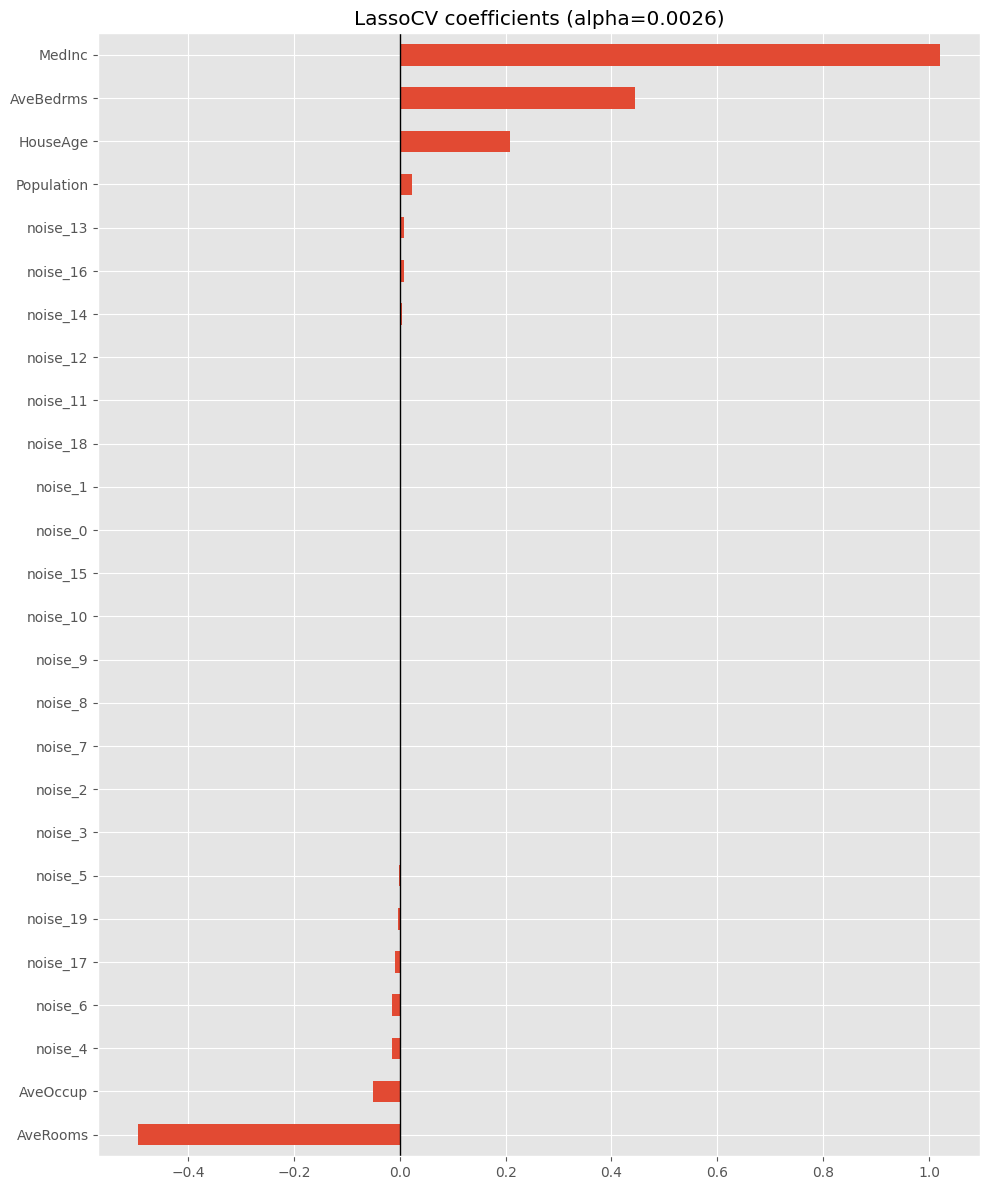

In [32]:
coef_cv.sort_values().plot(kind="barh", figsize=(10, 12))
plt.axvline(0, color="black", linewidth=1)
plt.title(f"LassoCV coefficients (alpha={lasso_cv.alpha_:.4f})")
plt.tight_layout()
plt.show()

## 11. 元の特徴量とノイズ特徴量を分けて確認

LASSO が残した特徴量のうち、元の特徴量と人工ノイズがどうなっているかを確かめる。

In [33]:
selected_original = coef_cv.loc[original_features][coef_cv.loc[original_features] != 0]
selected_noise = coef_cv.loc[noise_features][coef_cv.loc[noise_features] != 0]

print("Selected original features:", list(selected_original.index))
print("Number of selected original features:", len(selected_original))
print("Number of selected noise features   :", len(selected_noise))

if len(selected_noise) > 0:
    display(selected_noise.sort_values(key=np.abs, ascending=False))
else:
    print("No noise feature survived LASSO in this run.")

Selected original features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
Number of selected original features: 6
Number of selected noise features   : 9


,0
noise_4,-0.014791
noise_6,-0.014012
noise_13,0.008783
noise_17,-0.008438
noise_16,0.007431
noise_19,-0.004035
noise_14,0.003430
noise_5,-0.001342
noise_12,0.000908
